# RadCAT 
Radar column aircraft track code. Within this code aircraft time and position will be compared against radar data and then appropriate matches bewtween the radar sweeps, azimuths, and ranges will be made so that a representation of the most up to date environment around the aircraft can be displayed as a time series. This can allow for further comparisons between in-situ measured observations from the Citation research jet and the ground based C-SAPR radar observations during the MC3E field campaign. 

In [58]:
# Time to code up some BS 
import pyart
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.feature as cfeature
import xarray as xr
import os
import pandas as pd
import time
import io
import cmweather
from datetime import datetime
import numpy as np
import matplotlib.ticker as ticker
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.transforms as mtransforms
from matplotlib.gridspec import GridSpec
from csu_radartools import csu_fhc
from matplotlib.colors import ListedColormap

In [37]:
#=================================================
# Hydrometeor phase calculation code using 
# CSU radar tools python library to find which 
# hydrometeor phase the aircraft is suppose to be 
# in.
#=================================================

precip_classes = ['Drizzel', 'Rain', 'Ice Crystals', 'Aggregates', 'Wet Snow', 'Vertical Ice', 'Low-Density Graupel', 'High-Density Graupel', 'Hail', 'Big Drops']

def classify_summer(radar, rtemp, sweep):
    dbz = radar.variables['corrected_reflectivity_horizontal'].data[sweep]
    zdr = radar.variables['diff_reflectivity'].data[sweep]
    kdp = radar.variables['diff_phase'].data[sweep]
    rhv = radar.variables['copol_coeff'].data[sweep]
    score = csu_fhc.csu_fhc_summer(dz=dbz, zdr=zdr, rho=rhv, kdp=kdp, use_temp=True, band='C', T=rtemp)
    return score

In [17]:
# ASSOCIATED SUDO RHI SCAN AND REFLECTIVITY TIME SERIES CODE

#===============================================================
# This block of code looks at both radar times and aircraft times
# and generates a surrounding environment radar scan based on
# the location and timing of the aircraft during observations.
#===============================================================

# Initial read in of all possible radar times that could be plotted 
with os.scandir('C-SAPR_May_20_2011/') as entries:
    radar_files = list(entries)

# List creation of all possible radar files 
radar_file_times = []
for x in range(len(radar_files)):
    radar_file_times.append((int(radar_files[x].name[30:36][0:2]) * 3600) + (int(radar_files[x].name[30:36][2:4]) * 60) + (int(radar_files[x].name[30:36][4:6])))

# Open cloud microphysics file to eventually append it.
cloud_micro = xr.open_dataset('flight_data/11_05_20_Aircraft.nc')

# Generate empty data array for radar sweeps to be populated in
times = cloud_micro.Time.data  
sweep_options = ['below', 'in', 'above']
cloud_micro_radar = xr.DataArray(
    data = np.nan, 
    dims=["Time", "sweep"],
    coords={"Time": times, "sweep": sweep_options})

# Looping through radar files to populate the radar sweep array with data 
for number_files in range(len(radar_file_times) - 1):
    
    # Read in of both data files that will be later compared against aircraft times
    data1 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files].name)
    data2 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files + 1].name)

    # Code to find the start and end range of times that aircraft data can be compared against 
    file_start_time = radar_file_times[number_files] + data1.extract_sweeps([data1.nsweeps - 1]).time['data'].max()
    file_end_time = radar_file_times[number_files + 1] + data2.extract_sweeps([data2.nsweeps - 1]).time['data'].max()

    # Looping through every tenth aircraft time
    for time in range(len(cloud_micro_radar.Time.data)):

        # If statement to find which aircraft times are within the radar time range 
        if cloud_micro_radar.Time.data[time] >= file_start_time and cloud_micro_radar.Time.data[time] < file_end_time:

            # Find the sweep that is appropriate to the aircrafts position 
            vert_radar_profile = pyart.util.columnsect.get_field_location(data2, cloud_micro.POS_Lat.data[time], cloud_micro.POS_Lon.data[time])
            sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cloud_micro.POS_Alt.data[time])))

            # Find if the sweep is within a valid time range or not
            sweep_time = data2.extract_sweeps([sweep]).time['data'].max()
            if (sweep_time + radar_file_times[number_files + 1]) <= cloud_micro_radar.Time.data[time]:
                
                # Find if the sweep is at the lowest or highest position
                if sweep == 0 or sweep == data2.nsweeps - 1:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan

                # Otherwise return regular above, on, and below sweeps
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]
            
                # Saving of sudo RHI plots for analysis to make sure code is performing correct actions
                radar_lat = data2.latitude['data'][0]
                radar_lon = data2.longitude['data'][0]
    
                radar_azimuth = pyart.util.for_azimuth(radar_lat, cloud_micro.POS_Lat.data[time], radar_lon, cloud_micro.POS_Lon.data[time])
                aircraft_distance = pyart.util.sphere_distance(radar_lat, cloud_micro.POS_Lat.data[time], radar_lon, cloud_micro.POS_Lon.data[time]) / 1000
                
                display = pyart.graph.RadarMapDisplay(data2)
                fig, ax = plt.subplots(figsize=(12, 10))
                display.plot_azimuth_to_rhi(field = 'corrected_reflectivity_horizontal', 
                               ax = ax, 
                               target_azimuth = radar_azimuth, 
                               vmin = -30,
                               vmax = 70,
                               cmap = 'ChaseSpectral')
                ax.plot(aircraft_distance, (cloud_micro.POS_Alt.data[time]/1000) - .3276, marker = '+', color = 'black')
                ax.plot(aircraft_distance, (vert_radar_profile.corrected_reflectivity_horizontal.height.data[sweep + 1]/1000) - .3276, marker = 'D', color = 'black', markersize = 4)
                ax.plot(aircraft_distance, (vert_radar_profile.corrected_reflectivity_horizontal.height.data[sweep - 1]/1000) - .3276, marker = 'D', color = 'black', markersize = 4)
                ax.axvline(x = aircraft_distance, color = 'black', linestyle = '--', linewidth = .5)
                ax.set_ylim(0, 15)
                plt.savefig(f'images/{time}.png')
                plt.close()
            
            
            # Otherwise if the sweep is not within a valid time use the data1 file for sweep return
            else:
                vert_radar_profile = pyart.util.columnsect.get_field_location(data1, cloud_micro.POS_Lat.data[time], cloud_micro.POS_Lon.data[time])
                sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cloud_micro.POS_Alt.data[time])))
                
                # Find if the sweep is at the lowest or highest position
                if sweep == 0 or sweep == data1.nsweeps - 1:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan

                # Otherwise return regular above, on, and below sweeps
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]    
            
                # Saving of sudo RHI plots for analysis to make sure code is performing correct actions
                radar_lat = data1.latitude['data'][0]
                radar_lon = data1.longitude['data'][0]
    
                radar_azimuth = pyart.util.for_azimuth(radar_lat, cloud_micro.POS_Lat.data[time], radar_lon, cloud_micro.POS_Lon.data[time])
                aircraft_distance = pyart.util.sphere_distance(radar_lat, cloud_micro.POS_Lat.data[time], radar_lon, cloud_micro.POS_Lon.data[time]) / 1000
                
                display = pyart.graph.RadarMapDisplay(data1)
                fig, ax = plt.subplots(figsize=(12, 10))
                display.plot_azimuth_to_rhi(field = 'corrected_reflectivity_horizontal', 
                               ax = ax, 
                               target_azimuth = radar_azimuth, 
                               vmin = -30,
                               vmax = 70,
                               cmap = 'ChaseSpectral')
                ax.plot(aircraft_distance, (cloud_micro.POS_Alt.data[time]/1000) - .3276, marker = '+', color = 'black')
                ax.plot(aircraft_distance, (vert_radar_profile.corrected_reflectivity_horizontal.height.data[sweep + 1]/1000) - .3276, marker = 'D', color = 'black', markersize = 4)
                ax.plot(aircraft_distance, (vert_radar_profile.corrected_reflectivity_horizontal.height.data[sweep - 1]/1000) - .3276, marker = 'D', color = 'black', markersize = 4)
                ax.axvline(x = aircraft_distance, color = 'black', linestyle = '--', linewidth = .5)
                ax.set_ylim(0, 15)
                plt.savefig(f'images/{time}.png')
                plt.close()

            reflec_data = [reflec_data_below, reflec_data_ontop, reflec_data_above]
            cloud_micro_radar.loc[{'Time' : cloud_micro_radar.Time.data[time]}] = reflec_data

# Combining of datasets into one 
cloud_micro_radar = cloud_micro_radar.to_dataset(name = 'Radar_Reflectivity')
Data = xr.concat([cloud_micro, cloud_micro_radar], dim="Time")

In [44]:
# REFLECTIVITY/CLOUD PHASE TIME SERIES CODE 

#===============================================================
# This block of code looks at both radar times and aircraft times
# and generates a surrounding environment radar scan based on
# the location and timing of the aircraft during observations.
#===============================================================

# Initial read in of all possible radar times that could be plotted 
with os.scandir('C-SAPR_May_20_2011/') as entries:
    radar_files = list(entries)

# List creation of all possible radar files 
radar_file_times = []
for x in range(len(radar_files)):
    radar_file_times.append((int(radar_files[x].name[30:36][0:2]) * 3600) + (int(radar_files[x].name[30:36][2:4]) * 60) + (int(radar_files[x].name[30:36][4:6])))

# Open cloud microphysics file to eventually append it.
cloud_micro = xr.open_dataset('flight_data/11_05_20_Aircraft.nc')

# Generate empty data array for radar sweeps to be populated in
times = cloud_micro.Time.data  
sweep_options = ['below', 'in', 'above']
reflec_data_array = xr.DataArray(
    data = np.nan, 
    dims=["Time", "sweep"],
    coords={"Time": times, "sweep": sweep_options})

phase_data_array = xr.DataArray(
    data = np.nan, 
    dims=["Time"],
    coords={"Time": times})

# Looping through radar files to populate the radar sweep array with data 
for number_files in range(len(radar_file_times) - 1):
    
    # Read in of both data files that will be later compared against aircraft times
    data1 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files].name)
    data2 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files + 1].name)

    # Code to find the start and end range of times that aircraft data can be compared against 
    file_start_time = radar_file_times[number_files] + data1.extract_sweeps([data1.nsweeps - 1]).time['data'].max()
    file_end_time = radar_file_times[number_files + 1] + data2.extract_sweeps([data2.nsweeps - 1]).time['data'].max()

    # Looping through every tenth aircraft time
    for time in range(len(cloud_micro.Time.data)):

        # If statement to find which aircraft times are within the radar time range 
        if cloud_micro.Time.data[time] >= file_start_time and cloud_micro.Time.data[time] < file_end_time:

            # Find the sweep that is appropriate to the aircrafts position 
            vert_radar_profile = pyart.util.columnsect.get_field_location(data2, cloud_micro.POS_Lat.data[time], cloud_micro.POS_Lon.data[time])
            sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cloud_micro.POS_Alt.data[time])))

            # Find if the sweep is within a valid time range or not
            sweep_time = data2.extract_sweeps([sweep]).time['data'].max()
            if (sweep_time + radar_file_times[number_files + 1]) <= cloud_micro.Time.data[time]:
                
                # Find if the sweep is at the lowest or highest position
                if sweep == 0 or sweep == data2.nsweeps - 1:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan

                # Otherwise return regular above, on, and below sweeps
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]
            
            # Otherwise if the sweep is not within a valid time use the data1 file for sweep return
            else:
                vert_radar_profile = pyart.util.columnsect.get_field_location(data1, cloud_micro.POS_Lat.data[time], cloud_micro.POS_Lon.data[time])
                sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cloud_micro.POS_Alt.data[time])))
                
                # Find if the sweep is at the lowest or highest position
                if sweep == 0 or sweep == data1.nsweeps - 1:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan

                # Otherwise return regular above, on, and below sweeps
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]    

            # Code to calculate hydrometeor phase given vertical column 
            hydro_class = classify_summer(vert_radar_profile, float(cloud_micro.Air_Temp.sel(Time = cloud_micro.Time.data[time])), sweep)
            
            reflec_data = [reflec_data_below, reflec_data_ontop, reflec_data_above]
            reflec_data_array.loc[{'Time' : reflec_data_array.Time.data[time]}] = reflec_data
            phase_data_array.loc[{'Time' : phase_data_array.Time.data[time]}] = hydro_class

# Combining of datasets into one 
reflec_data_array = reflec_data_array.to_dataset(name = 'Radar_Reflectivity')
phase_data_array = phase_data_array.to_dataset(name = 'Phase_Classification')
Data = xr.combine_by_coords([cloud_micro, reflec_data_array, phase_data_array])

# Fixes encoding error after concat
for var in Data.data_vars:
    Data[var].encoding = {}
Data['Time'].encoding.clear()


# Save data to netcdf file within flight data directory 
Data.to_netcdf('flight_data/11_05_20_Microphysics.nc')

In [2]:
#=====================================
# This code is meant to generate
# a display of aircraft and radar data
# in a four panel user interactable
# interface
#=====================================

# Read in cloud microphysics with radar scan data file 
cloud_micro = xr.open_dataset('flight_data/11_05_20_Microphysics.nc')

# Phase classifications list
precip_classes = ['Drizzel', 'Rain', 'Ice Crystals', 'Aggregates', 'Wet Snow', 'Vertical Ice', 'Low-Density Graupel', 'High-Density Graupel', 'Hail', 'Big Drops']

# Read through directory with HVPS images
with os.scandir('flight_data/HVPS3_Images/') as entries:
    hvps_files = list(entries)

# Convert file names to seconds from midnight for comparison scripts later used
hvps_files_list = []
for entry in hvps_files:
    hvps_files_list.append((int(entry.name[9:15][0:2]) * 3600) + (int(entry.name[9:15][2:4]) * 60) + int(entry.name[9:15][4:6]))
hvps_files_list = np.array(hvps_files_list)

# Read through directory with Aircraft PPI images 
with os.scandir('radar_images2/') as entries:
    radar_files = list(entries)

# Convert file names to seconds from midnight for comparison scripts later used 
radar_file_list = []
for entry in radar_files:
    radar_file_list.append((int(entry.name[30:36][0:2]) * 3600) + (int(entry.name[30:36][2:4]) * 60) + int(entry.name[30:36][4:6]))
radar_file_list = np.array(radar_file_list)

# Define buttons that will be used for the display control 
forward = widgets.Button(description=">")
backward = widgets.Button(description="<")
output = widgets.Output()

# Define initial counter variable for indexing of radar files
counter = 0

# Plotting function 
def plotting_func(counter):
            # Defines what data products should be plotted 
        radar_file_plot = radar_files[counter]
        hvps_image = plt.imread(f'flight_data/HVPS3_Images/{hvps_files[np.argmin(abs(hvps_files_list - radar_file_list[counter]))].name}')
        matrix = np.asarray(hvps_image)
        
        # Finds the appropriate time index for aircraft data to be plotted 
        time = np.argmin(abs(np.array(cloud_micro.Time.data) - radar_file_list[counter]))

        # Clear any output that may be displayed before plotting new display
        clear_output(wait=True)
        
        # Define figure and axis that the data will be plotted on 
        fig = plt.figure(figsize =(12, 8))
        
        gs = GridSpec(4, 15, figure=fig)
        ax1 = fig.add_subplot(gs[0:3, 0:10])
        ax2 = fig.add_subplot(gs[0:, -4:])
        ax3 = fig.add_subplot(gs[3:, 0:4])
        ax4 = fig.add_subplot(gs[3:, 6:10])
        
        # Plot radar PPI with aircraft overlay
        image_radar = plt.imread(f'radar_images2/{radar_file_plot.name}')
        ax1.imshow(image_radar)
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax1.set_title('C-SAPR Ground Radar PPI Scan at Aircraft Altitude', fontsize = 10)

        # Phase classification label 
        ax1.text(0.5, 0.02, f'BEST GUESS PRECIP TYPE: {precip_classes[int(cloud_micro.Phase_Classification[time].data)]}', 
                color = 'red',
                fontsize = 10,
                horizontalalignment='center', 
                verticalalignment='bottom', 
                transform=ax1.transAxes)

        # HVPS-3 Particle image display
        ax2.imshow(hvps_image)
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax2.set_title('HVPS-3 Particle Images', fontsize = 10)
        ax2.set_xlabel(f'{hvps_files[np.argmin(abs(hvps_files_list - radar_file_list[counter]))].name}')
        
        # Altitude/Temperature time series plot
        try:
            cloud_micro.POS_Alt[0:time].plot(ax = ax3, color = 'black')
            ax3.axvline(x=cloud_micro.Time.data[time], color='black', linestyle = '--', linewidth = .5)

            # Altitude plot
            ax3.plot([cloud_micro.Time.data[0], cloud_micro.Time.data[time]], [cloud_micro.POS_Alt.data[time], cloud_micro.POS_Alt.data[time]], color = 'black', linestyle = '--', linewidth = .5)
            ax3.plot(cloud_micro.Time.data[time], cloud_micro.POS_Alt.data[time], color = 'black', marker = 'o', markersize = 5)

            # Temperature plot
            ax5 = ax3.twinx()
            cloud_micro.Air_Temp[0:time].plot(ax = ax5)
            ax5.plot(cloud_micro.Time.data[time], cloud_micro.Air_Temp.data[time], color = 'blue', marker = 'o', markersize = 5)
            ax5.set_ylabel('Air Temperature (C)')
            
            ax3.set_title('Aircraft Altitude/Temperature Time Series', fontsize = 10)
            ax3.set_xlim([cloud_micro.Time.data[0], cloud_micro.Time.data[time] + 100])
            ax3.set_xlabel('Time (sfm)')
            ax3.set_ylabel('Altitude (m)')
            
        except:
            ax3.set_title('Aircraft Altitude Time Series', fontsize = 10)
            ax3.text(.5, .5, 'No Available Data')

        # HVPS particle size distribution plot
        try:
            hvps_data = [cloud_micro.HVPS_Ch1.data[time], cloud_micro.HVPS_Ch2.data[time], cloud_micro.HVPS_Ch3.data[time], cloud_micro.HVPS_Ch4.data[time], 
                         cloud_micro.HVPS_Ch5.data[time], cloud_micro.HVPS_Ch6.data[time], cloud_micro.HVPS_Ch7.data[time], cloud_micro.HVPS_Ch8.data[time],
                         cloud_micro.HVPS_Ch9.data[time], cloud_micro.HVPS_Ch10.data[time], cloud_micro.HVPS_Ch11.data[time], cloud_micro.HVPS_Ch12.data[time],
                         cloud_micro.HVPS_Ch13.data[time], cloud_micro.HVPS_Ch14.data[time], cloud_micro.HVPS_Ch15.data[time], cloud_micro.HVPS_Ch16.data[time],
                         cloud_micro.HVPS_Ch17.data[time], cloud_micro.HVPS_Ch18.data[time], cloud_micro.HVPS_Ch19.data[time], cloud_micro.HVPS_Ch20.data[time],
                         cloud_micro.HVPS_Ch21.data[time], cloud_micro.HVPS_Ch22.data[time], cloud_micro.HVPS_Ch23.data[time], cloud_micro.HVPS_Ch24.data[time],
                         cloud_micro.HVPS_Ch25.data[time], cloud_micro.HVPS_Ch26.data[time], cloud_micro.HVPS_Ch27.data[time], cloud_micro.HVPS_Ch28.data[time]]  
            
            # Bin name descriptions
            hvps_desc = ['300 um', '500 um', '700 um', '900 um',
                         '1100 um', '1300 um', '1500 um', '1700 um',
                         '2000 um', '2400 um', '2800 um', '3200 um',
                         '3600 um', '4000 um', '4400 um', '4800 um', 
                         '5500 um', '6500 um', '7500 um', '8500 um', 
                         '9500 um', '11000 um', '13000 um', '15000 um', 
                         '17000 um', '19000 um', '22500 um', '27500 um']
            
            # Plotting of HVPS PSD data 
            ax4.bar(hvps_desc, hvps_data)
            ax4.tick_params(axis='x', labelrotation=-90)
            ax4.set_ylabel('Concentration (#/cm^3)')
            ax4.set_xlabel('Bin size (um)')
            ax4.tick_params(axis='both', labelsize=5)
            ax4.set_title('HVPS-3 Particle Size Distribution', fontsize = 10)

        except:
            ax4.set_title('HVPS-3 Particle Size Distribution', fontsize = 10)
            
        plt.show()


# Function for forward button click
def forward_button_click(b):
    with output:
        # Counter logic
        global counter 
        counter += 1
        if counter == len(radar_file_list):
            counter = 0

        plotting_func(counter)

        
# Function for backward button click 
def backward_button_click(b):
    with output:
        # Counter logic
        global counter 
        counter -= 1
        if counter < 0:
            counter = len(radar_file_list) - 1

        plotting_func(counter)
  
        
forward.on_click(forward_button_click)
backward.on_click(backward_button_click)
display(widgets.HBox([backward, forward]), output)

Output()

In [2]:
#=======================================
# Code to generate the reflectivity 
# value given particle size distribtuion
# from the HVPS-3
#========================================

# Open cloud microphysics file to eventually append it.
cloud_micro = xr.open_dataset('flight_data/11_05_20_Microphysics.nc')

# Generate empty data array for calculated reflectivity to be populated in
times = cloud_micro.Time.data
cloud_micro_radar = xr.DataArray(
    data = np.nan, 
    dims=["Time"],
    coords={"Time": times})

for index in range(len(cloud_micro.HVPS_Ch1)):
    hvps_data = np.array([cloud_micro.HVPS_Ch1.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch2.sel(Time = cloud_micro.Time.data[index]), 
                  cloud_micro.HVPS_Ch3.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch4.sel(Time = cloud_micro.Time.data[index]), 
                  cloud_micro.HVPS_Ch5.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch6.sel(Time = cloud_micro.Time.data[index]), 
                  cloud_micro.HVPS_Ch7.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch8.sel(Time = cloud_micro.Time.data[index]),
                  cloud_micro.HVPS_Ch9.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch10.sel(Time = cloud_micro.Time.data[index]),
                  cloud_micro.HVPS_Ch11.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch12.sel(Time = cloud_micro.Time.data[index]),
                  cloud_micro.HVPS_Ch13.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch14.sel(Time = cloud_micro.Time.data[index]), 
                  cloud_micro.HVPS_Ch15.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch16.sel(Time = cloud_micro.Time.data[index]),
                  cloud_micro.HVPS_Ch17.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch18.sel(Time = cloud_micro.Time.data[index]),
                  cloud_micro.HVPS_Ch19.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch20.sel(Time = cloud_micro.Time.data[index]),
                  cloud_micro.HVPS_Ch21.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch22.sel(Time = cloud_micro.Time.data[index]), 
                  cloud_micro.HVPS_Ch23.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch24.sel(Time = cloud_micro.Time.data[index]),
                  cloud_micro.HVPS_Ch25.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch26.sel(Time = cloud_micro.Time.data[index]), 
                  cloud_micro.HVPS_Ch27.sel(Time = cloud_micro.Time.data[index]), cloud_micro.HVPS_Ch28.sel(Time = cloud_micro.Time.data[index])])

    hvps_bin_sizes = np.array([300, 500, 700, 900, 1100, 
                               1300, 1500, 1700, 2000, 2400, 
                               2800, 3200, 3600, 4000, 4400, 
                               4800, 5500, 6500, 7500, 8500, 
                               9500, 11000, 13000, 15000, 
                               17000, 19000, 22500, 27500])

    hvps_data = hvps_bin_sizes * hvps_data
    
    hvps_bin_sizes = hvps_bin_sizes * .001 # Convert to mm 
    hvps_bin_sizes = hvps_bin_sizes ** 6 # Convert to D^6 for reflectivity calculation

    reflec_air = hvps_data * hvps_bin_sizes
    reflec_air = reflec_air * 1000000
    reflec_air =  10 * np.log10(reflec_air.sum()) * .19

    cloud_micro_radar.loc[{'Time' : cloud_micro_radar.Time.data[index]}] = reflec_air

# Combining of datasets into one 
cloud_micro_radar = cloud_micro_radar.to_dataset(name = 'Calculated_Reflectivity')
Data = xr.combine_by_coords([cloud_micro, cloud_micro_radar])

# Fixes encoding error after concat
for var in Data.data_vars:
    Data[var].encoding = {}
Data['Time'].encoding.clear()

# Save data to netcdf file within flight data directory 
Data.to_netcdf('flight_data/11_05_20_Test.nc')

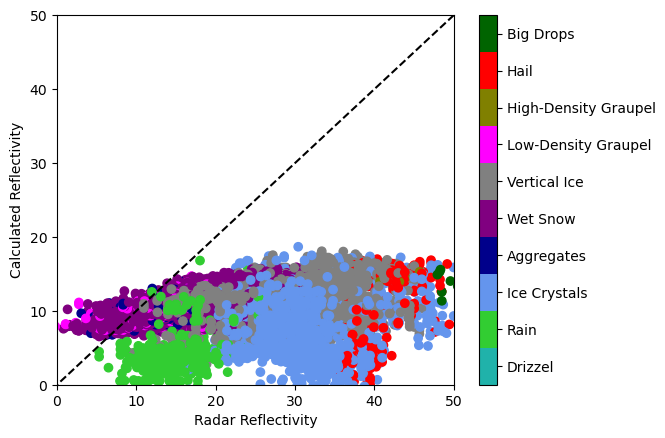

In [106]:
#===========================================
# Code to visualize the comparison between
# aircraft calculated reflectivity and radar
# reflectivity
#===========================================

aircraft_data = xr.open_dataset('flight_data/11_05_20_Microphysics2.nc')
list_type = time_list

radar_ref = (aircraft_data.Radar_Reflectivity.sel(Time = list_type)[:, 1])
calc_ref = aircraft_data.Calculated_Reflectivity.sel(Time = list_type)
phase_class = aircraft_data.Phase_Classification.sel(Time = list_type)

color_bar_labels = ['Drizzel', 'Rain', 'Ice Crystals', 'Aggregates', 'Wet Snow', 'Vertical Ice', 'Low-Density Graupel', 'High-Density Graupel', 'Hail', 'Big Drops']
color_map = ['lightseagreen', 'limegreen', 'cornflowerblue', 'darkblue', 'purple', 'gray', 'magenta', 'olive', 'red', 'darkgreen']
color_map = ListedColormap(color_map)
bounds = np.arange(len(color_bar_labels) + 1) 
label_positions = bounds[:-1] + .5

plt.scatter(x = radar_ref, 
            y = calc_ref, 
            c = phase_class, 
            cmap = color_map, 
           vmin = 0, 
           vmax = 10)
plt.ylabel('Calculated Reflectivity')
plt.xlabel('Radar Reflectivity')
plt.xlim(0, 50)
plt.ylim(0, 50)
plot = plt.plot((50, 0), (50, 0), color = 'black', linestyle = '--')
cbar = plt.colorbar()
cbar.set_ticks(ticks = label_positions, labels = color_bar_labels)
plt.show()

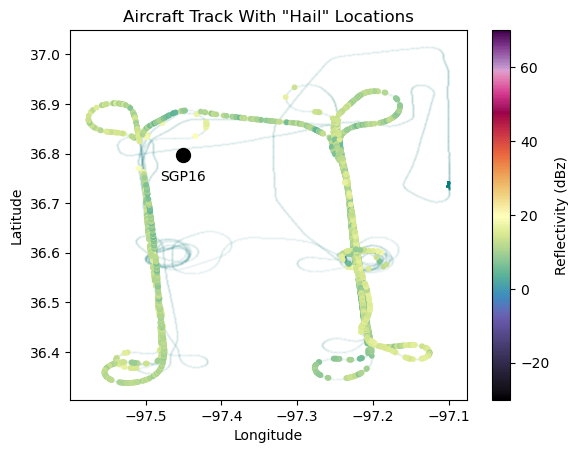

In [101]:
list_type = one_to_one_list
plt.scatter(x = aircraft_data.POS_Lon, 
            y = aircraft_data.POS_Lat, 
            marker = 'o', 
            s = 1, 
            color = 'teal', 
           alpha = .025)

plt.scatter(x = aircraft_data.POS_Lon.sel(Time = list_type), 
            y = aircraft_data.POS_Lat.sel(Time = list_type), 
            c = aircraft_data.Radar_Reflectivity.sel(Time = list_type)[:, 1], 
            cmap = 'ChaseSpectral',
            vmin = -30, 
            vmax = 70,
            s = 10)

plt.title('Aircraft Track With "Hail" Locations')
plt.colorbar(label = 'Reflectivity (dBz)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.annotate('SGP16', xy = (-97.45054626464844, 36.74615783691406),ha = 'center')
plt.plot(-97.45054626464844, 36.79615783691406, marker = 'o', color = 'black', markersize = 10)
plt.show()

In [ ]:
print(wet_snow_list[4300:4500])

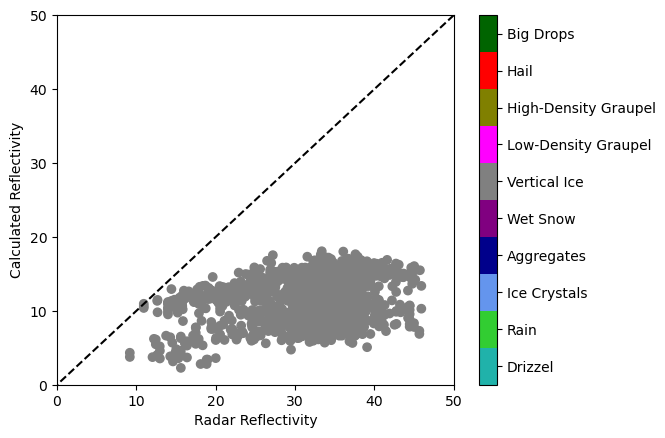

In [22]:
#===========================================
# Code to visualize the comparison between
# aircraft calculated reflectivity and radar
# reflectivity
#===========================================

list_type = vertical_ice_list

radar_ref = aircraft_data.Radar_Reflectivity.sel(Time = list_type)[:, 1]
calc_ref = aircraft_data.Calculated_Reflectivity.sel(Time = list_type)
phase_class = aircraft_data.Phase_Classification.sel(Time = list_type)

color_bar_labels = ['Drizzel', 'Rain', 'Ice Crystals', 'Aggregates', 'Wet Snow', 'Vertical Ice', 'Low-Density Graupel', 'High-Density Graupel', 'Hail', 'Big Drops']
color_map = ['lightseagreen', 'limegreen', 'cornflowerblue', 'darkblue', 'purple', 'gray', 'magenta', 'olive', 'red', 'darkgreen']
color_map = ListedColormap(color_map)
bounds = np.arange(len(color_bar_labels) + 1) 
label_positions = bounds[:-1] + .5

plt.scatter(x = radar_ref, 
            y = calc_ref, 
            c = phase_class, 
            cmap = color_map, 
           vmin = 0, 
           vmax = 10)
plt.ylabel('Calculated Reflectivity')
plt.xlabel('Radar Reflectivity')
plt.xlim(0, 50)
plt.ylim(0, 50)
plot = plt.plot((50, 0), (50, 0), color = 'black', linestyle = '--')
cbar = plt.colorbar()
cbar.set_ticks(ticks = label_positions, labels = color_bar_labels)
plt.show()

In [22]:
print(aircraft_data.Nev_TWC.sel(Time = 56606.09).data)
print(aircraft_data.Nev_LWCcor.sel(Time = 56606.09).data)
print(aircraft_data.Radar_Reflectivity.sel(Time = 56606.09).data)

-0.0006
0.0049
[28.765625  37.234375  23.0859375]


In [6]:
#=======================================
# Aircraft track classification 
# code. This will identify all of the 
# different phases of flight that the 
# aircraft is in to support reflectivity 
# analysis.
#=======================================
aircraft_data = xr.open_dataset('flight_data/11_05_20_Microphysics2.nc')
time_list = [float(number) for number in aircraft_data.Time.data]

# This code below will find where the aircraft was in straight or turning flight 
turning_list = []
heading = aircraft_data.POS_Head.data
for index in range(5, len(heading), 1):
    if (abs(heading[index] - heading[index - 5]) % 360) > 5:
        turning_list.append(float(aircraft_data.Time[index].data))

remove_list = set(turning_list)
straight_list = [item for item in time_list if item not in remove_list]

# This code below will find in the aircraft was changing altitude or at level flight 
altitude_change_list = []
altitude = aircraft_data.POS_Alt
for index in range(5, len(altitude), 1):
    if (abs(altitude[index] - altitude[index - 5])) > 5:
        altitude_change_list.append(float(aircraft_data.Time[index].data))

alt_remove_list = set(altitude_change_list)
level_list = [item for item in time_list if item not in alt_remove_list]

In [21]:
vertical_ice_list = []
for index in aircraft_data.Time:
    if aircraft_data.Phase_Classification.sel(Time = index) == 5:
        vertical_ice_list.append(index)

In [223]:
ice_crystal_list = []
for index in aircraft_data.Time:
    if aircraft_data.Phase_Classification.sel(Time = index) == 2:
        ice_crystal_list.append(index)

In [16]:
hail_list = []
for index in aircraft_data.Time:
    if aircraft_data.Phase_Classification.sel(Time = index) == 8:
        hail_list.append(index)

In [28]:
wet_snow_list = []
for index in aircraft_data.Time:
    if aircraft_data.Phase_Classification.sel(Time = index) == 4:
        wet_snow_list.append(index)

In [98]:
one_to_one_list = []
for index in aircraft_data.Time:
    try:
        if abs(int(aircraft_data.Radar_Reflectivity.sel(Time = index)[1]) - int(aircraft_data.Calculated_Reflectivity.sel(Time = index))) < 5:
            one_to_one_list.append(index)
    except:
        continue

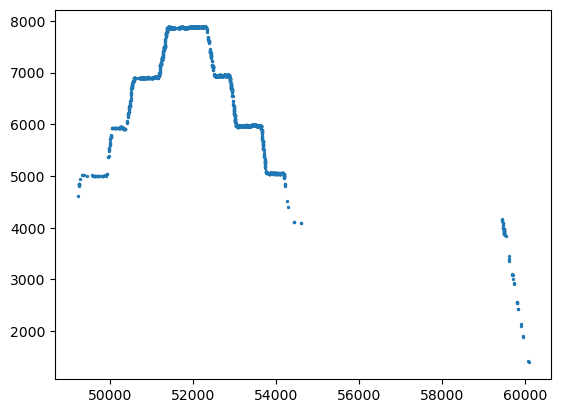

In [103]:
list_type = one_to_one_list
plt.scatter(aircraft_data.Time.sel(Time = list_type), 
            aircraft_data.POS_Alt.sel(Time = list_type), 
           s = 2)

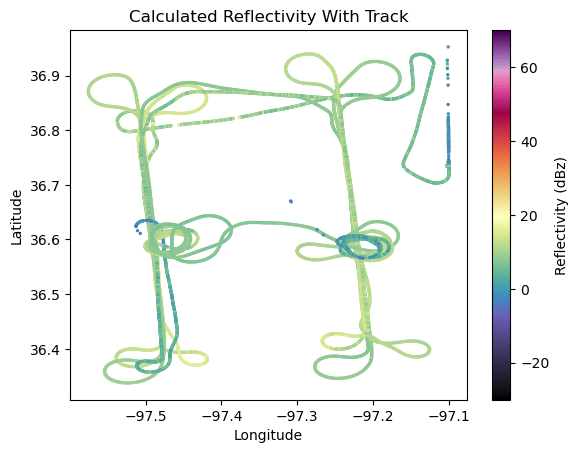

In [312]:
list_type = time_list
plt.scatter(x = aircraft_data.POS_Lon.sel(Time = list_type), 
            y = aircraft_data.POS_Lat.sel(Time = list_type), 
            c = aircraft_data.Calculated_Reflectivity.sel(Time = list_type), 
            cmap = 'ChaseSpectral',
            vmin = -30, 
            vmax = 70,
            s = 2)
plt.title('Calculated Reflectivity With Track')
plt.colorbar(label = 'Reflectivity (dBz)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [66]:
#=================================================
# Hydrometeor phase calculation code using 
# CSU radar tools python library to find which 
# hydrometeor phase the aircraft is suppose to be 
# in.
#=================================================

precip_classes = ['Drizzel', 'Rain', 'Ice Crystals', 'Aggregates', 'Wet Snow', 'Vertical Ice', 'Low-Density Graupel', 'High-Density Graupel', 'Hail', 'Big Drops']

def classify_summer(radar, rtemp, sweep):
    dbz = radar.variables['corrected_reflectivity_horizontal'].data[sweep]
    zdr = radar.variables['diff_reflectivity'].data[sweep]
    kdp = radar.variables['diff_phase'].data[sweep]
    rhv = radar.variables['copol_coeff'].data[sweep]
    score = csu_fhc.csu_fhc_summer(dz=dbz, zdr=zdr, rho=rhv, kdp=kdp, use_temp=True, band='C', T=rtemp)
    return precip_classes[score]

# This code below does not work but can, with only a small donation of your time it can work as soon as when ever you fix it...
'''
def classify_winter(radar):
    logging.info("Running CSU Winter classification")
    dz = np.ma.masked_array(radar.fields['DBZ']['data'])
    zdr = np.ma.masked_array(radar.fields['ZDR']['data'])
    kd = np.ma.masked_array(radar.fields['PHIDP']['data'])
    rh = np.ma.masked_array(radar.fields['RHOHV']['data'])
    sn = np.ma.masked_array(radar.fields['signal_to_noise_ratio']['data'])
    rtemp = radar.fields['sounding_temperature']['data']
    azimuths = radar.azimuth['data']
    heights_km = radar.fields['height']['data'] / 1000
    hcawinter = csu_fhc.run_winter(
        dz=dz, zdr=zdr, kdp=kd, rho=rh, azimuths=azimuths, sn_thresh=-30,
        expected_ML=2.0, sn=sn, T=rtemp, heights=heights_km, nsect=36,
        scan_type=radar.scan_type, verbose=False, use_temp=True, band='S', return_scores=False
    )
    return csu_winter_to_hp[hcawinter]

def classify_pyart(radar):
    logging.info("Running Py-ART classification")
    radar.instrument_parameters['frequency'] = {'long_name': 'Radar frequency', 'units': 'Hz', 'data': [9.2e9]}
    hydromet_class = pyart.retrieve.hydroclass_semisupervised(
        radar,
        refl_field="corrected_reflectivity",
        zdr_field="corrected_differential_reflectivity",
        kdp_field="filtered_corrected_specific_diff_phase",
        rhv_field="RHOHV",
        temp_field="sounding_temperature",
    )
    return pyart_to_hp[hydromet_class['data']]
'''
# Do nothing line of code 
random_variable = 10

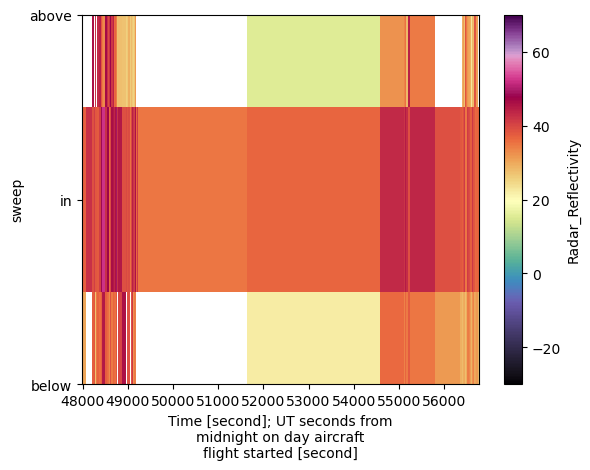

In [63]:
aircraft_data.Radar_Reflectivity.sel(Time = hail_list).plot(x = 'Time', 
                                                           cmap = 'ChaseSpectral',
                                                           vmin = -30, 
                                                           vmax = 70)

In [97]:
# Time of interest to analyze is 48442.09
time = 52000
hours = int(time // 3600)
minuets = int((time % 3600) // 60)
seconds = int((time % 3600) % 60)
print(f'{hours}:{minuets}:{seconds}')

14:26:40


Radar sweep 8
Aircraft Latitude: 36.558 Aircraft Longitude: -97.488
Aircraft Altitude: 3110.08154296875m
Aircraft Reflectivity: 52.296875 dBZ


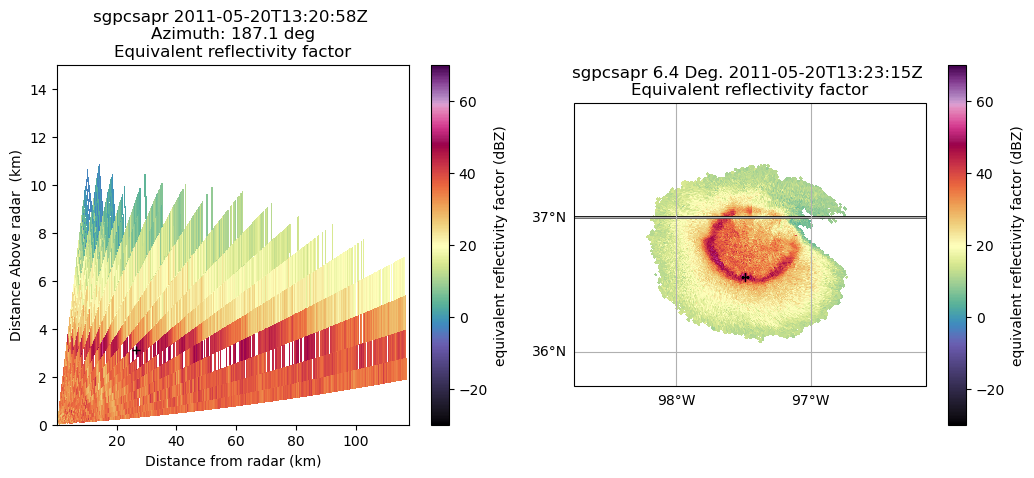

In [94]:
# Sudo RHI plotting code for CSU radar tools hail observation times 

data = pyart.io.read('C-SAPR_May_20_2011/sgpcsaprsurcmacI7.c0.20110520.132058.nc.v0')

aircraft_lat = float(aircraft_data.POS_Lat.sel(Time = 48442.09).data)
aircraft_lon = float(aircraft_data.POS_Lon.sel(Time = 48442.09).data)
aircraft_alt = float(aircraft_data.POS_Alt.sel(Time = 48442.09).data) / 1000

# Define parameters needed for plotting
radar_lat = data.latitude['data'][0]
radar_lon = data.longitude['data'][0]

radar_azimuth = pyart.util.for_azimuth(radar_lat, aircraft_lat, radar_lon, aircraft_lon)
aircraft_distance = pyart.util.sphere_distance(radar_lat, aircraft_lat, radar_lon, aircraft_lon) / 1000 # This converts to kilometers

# Convert the radar data to a graphable display object
display = pyart.graph.RadarMapDisplay(data)

# Define the projection used in the PPI map
projection = ccrs.PlateCarree()

# Set figure size for the plots
fig = plt.figure(figsize = (11,9))

# Define the axis for the RHI map plot
ax = fig.add_axes([0.06, 0.50, 0.40, 0.40])

# Plotting of the artifical RHI map
display.plot_azimuth_to_rhi(field = 'corrected_reflectivity_horizontal', 
                           ax = ax, 
                           target_azimuth = radar_azimuth, 
                           vmin = -30,
                           vmax = 70,
                           cmap = 'ChaseSpectral')

# This plots the location of the aircraft on the artifical RHI map
ax.plot(aircraft_distance - .3276, aircraft_alt, marker = '+', color = 'black')

# Limit set to the y-axis to make sure map is proportional 
ax.set_ylim(0, 15)

# Define the axis that the PPI map will be plotted to 
ax1 = fig.add_axes([0.53, 0.50, 0.40, 0.40], projection = projection)
ax1.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')

# This code will find the sweep that the aircraft is most closest to and plot it in the PPI map 
vert_radar_profile = pyart.util.columnsect.get_field_location(data, aircraft_lat, aircraft_lon)
sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (aircraft_alt * 1000)))

# PPI display map
display.plot_ppi_map('corrected_reflectivity_horizontal', 
                        ax = ax1,
                        sweep = sweep,
                        vmin = -30,
                        vmax = 70, 
                        cmap = 'ChaseSpectral')

# This plots the location of the aircraft on the PPI map
ax1.plot(aircraft_lon, aircraft_lat, marker = '+', color = 'black')

# This will find the reflectivity associated with the given location of the aircraft
aircraft_reflectivity = vert_radar_profile.corrected_reflectivity_horizontal.sel(height=(aircraft_alt * 1000), method = 'nearest').data

# Output of aircraft reflectivity and radar sweep that the aircraft is located in
#print(f'Aircraft Reflectivity: {round(int(aircraft_reflectivity), 0)}dBz')
print(f'Radar sweep {sweep + 1}')
print(f'Aircraft Latitude: {aircraft_lat:.3f} Aircraft Longitude: {aircraft_lon:.3f}')
print(f'Aircraft Altitude: {aircraft_alt * 1000}m')
print(f'Aircraft Reflectivity: {aircraft_reflectivity} dBZ')

plt.show()

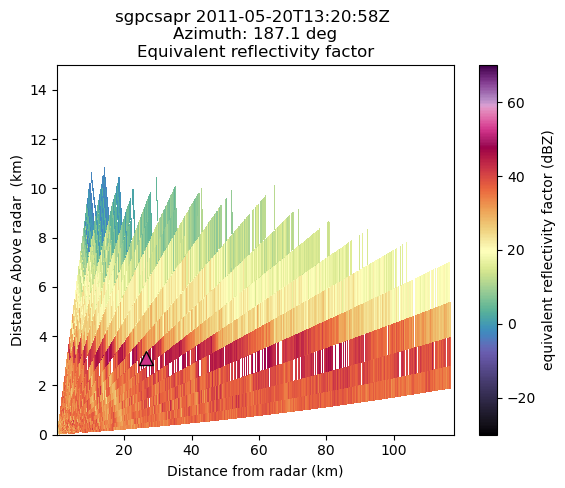

In [14]:
# Sudo RHI plotting code for CSU radar tools hail observation times 

data = pyart.io.read('C-SAPR_May_20_2011/sgpcsaprsurcmacI7.c0.20110520.132058.nc.v0')
aircraft_data = xr.open_dataset('flight_data/11_05_20_Microphysics2.nc')

aircraft_lat = float(aircraft_data.POS_Lat.sel(Time = 48442.09).data)
aircraft_lon = float(aircraft_data.POS_Lon.sel(Time = 48442.09).data)
aircraft_alt = float(aircraft_data.POS_Alt.sel(Time = 48442.09).data) / 1000

# Define parameters needed for plotting
radar_lat = data.latitude['data'][0]
radar_lon = data.longitude['data'][0]

radar_azimuth = pyart.util.for_azimuth(radar_lat, aircraft_lat, radar_lon, aircraft_lon)
aircraft_distance = pyart.util.sphere_distance(radar_lat, aircraft_lat, radar_lon, aircraft_lon) / 1000 # This converts to kilometers

# Convert the radar data to a graphable display object
display = pyart.graph.RadarMapDisplay(data)

# Plotting of the artifical RHI map
display.plot_azimuth_to_rhi(field = 'corrected_reflectivity_horizontal', 
                           target_azimuth = radar_azimuth, 
                           vmin = -30,
                           vmax = 70,
                           cmap = 'ChaseSpectral')

# Code to find reflectivity color the aircraft is in 
vert_radar_profile = pyart.util.columnsect.get_field_location(data, aircraft_lat, aircraft_lon)
sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (aircraft_alt * 1000)))

ref_val = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
cmap_data = plt.colormaps['ChaseSpectral']
ref_val_norm = (ref_val + 30) / (100)
point_color = cmap_data(ref_val_norm)

# This plots the location of the aircraft on the artifical RHI map
plt.plot(aircraft_distance - .3276, aircraft_alt, marker = '^', color = point_color, markersize = 10, markeredgecolor = 'black')

# Limit set to the y-axis to make sure map is proportional 
plt.ylim(0, 15)

plt.show()

In [43]:
with open('vertical_ice_times.txt', 'w') as file:
    file.write(','.join(str(item) for item in new_list))
file.close()

In [44]:
df = pd.read_csv("vertical_ice_times.txt", delimiter=",")

Empty DataFrame
Columns: [47662.09, 47665.09, 47717.09, 47718.09, 47732.09, 47733.09, 47748.09, 47763.09, 47764.09, 47779.09, 47780.09, 47785.09, 47786.09, 47791.09, 47795.09, 47797.09, 47800.09, 47823.09, 47834.09, 47835.09, 47841.09, 47843.09, 47860.09, 47861.09, 47868.09, 47869.09, 47877.09, 47879.09, 47880.09, 47890.09, 47892.09, 47894.09, 47895.09, 47907.09, 47910.09, 47920.09, 47924.09, 47926.09, 47927.09, 47928.09, 47929.09, 47931.09, 47933.09, 47934.09, 47936.09, 47939.09, 47941.09, 47945.09, 47948.09, 47957.09, 47958.09, 47960.09, 47961.09, 47968.09, 47970.09, 47972.09, 47973.09, 47974.09, 47976.09, 47977.09, 47979.09, 47981.09, 47982.09, 47983.09, 47985.09, 47986.09, 47989.09, 47990.09, 47991.09, 47992.09, 47993.09, 47996.09, 47998.09, 47999.09, 48000.09, 48001.09, 48002.09, 48004.09, 48005.09, 48006.09, 48007.09, 48008.09, 48009.09, 48010.09, 48011.09, 48012.09, 48014.09, 48015.09, 48016.09, 48017.09, 48018.09, 48019.09, 48020.09, 48021.09, 48023.09, 48024.09, 48025.09, 4802